# 📱 Mobile Price Range Prediction

## Level 2 - Task 4: Feature Engineering

### Objective

The objective of this task is to transform and prepare the mobile price range dataset for machine learning by encoding the target variable, scaling numerical features, detecting outliers, and identifying important features.

In [46]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv("MobilePriceRange.csv")

df.head()

,BatteryPower,InternalMemory,ClockSpeed,NoOfCores,RAM,TalkTime,DualSim,3G,4G,WiFi,...,MobileDepth,MobileWeight,TouchScreen,ScreenHeight,ScreenWidth,FrontCameraPx,RearCameraPX,PxHeight,PxWeight,PriceRange
0,842,7,2.2,2,2549,19,0,0,0,1,...,0.6,188,0,9,7,1,2,20,756,Medium
1,1021,53,0.5,3,2631,7,1,1,1,0,...,0.7,136,1,17,3,0,6,905,1988,High
2,563,41,0.5,5,2603,9,1,1,1,0,...,0.9,145,1,11,2,2,6,1263,1716,High
3,615,10,2.5,6,2769,11,0,1,0,0,...,0.8,131,0,16,8,0,9,1216,1786,High
4,1821,44,1.2,2,1411,15,0,1,1,0,...,0.6,141,1,8,2,13,14,1208,1212,Medium


In [48]:
print(df.shape)
print(df.columns.tolist())

(2000, 21)
['BatteryPower', 'InternalMemory', 'ClockSpeed', 'NoOfCores', 'RAM', 'TalkTime', 'DualSim', '3G', '4G', 'WiFi', 'Bluetooth', 'MobileDepth', 'MobileWeight', 'TouchScreen', 'ScreenHeight', 'ScreenWidth', 'FrontCameraPx', 'RearCameraPX', 'PxHeight', 'PxWeight', 'PriceRange']


In [49]:
X = df.drop("PriceRange", axis=1)
y = df["PriceRange"]

In [50]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2000, 20)
Target shape: (2000,)


In [51]:
price_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

y_encoded = y.map(price_mapping)

y_encoded.head()

,PriceRange
0,1.0
1,2.0
2,2.0
3,2.0
4,1.0


In [52]:
print(y_encoded.value_counts())

PriceRange
1.0    500
2.0    500
0.0    500
Name: count, dtype: int64


In [53]:
X.dtypes

,0
BatteryPower,int64
InternalMemory,int64
ClockSpeed,float64
NoOfCores,int64
RAM,int64
TalkTime,int64
DualSim,int64
3G,int64
4G,int64
WiFi,int64


In [54]:
minmax_scaler = MinMaxScaler()

X_normalized = minmax_scaler.fit_transform(X)

X_normalized = pd.DataFrame(
    X_normalized,
    columns=X.columns
)

X_normalized.head()

,BatteryPower,InternalMemory,ClockSpeed,NoOfCores,RAM,TalkTime,DualSim,3G,4G,WiFi,Bluetooth,MobileDepth,MobileWeight,TouchScreen,ScreenHeight,ScreenWidth,FrontCameraPx,RearCameraPX,PxHeight,PxWeight
0,0.227789,0.080645,0.68,0.142857,0.612774,0.944444,0.0,0.0,0.0,1.0,0.0,0.555556,0.900000,0.0,0.285714,0.388889,0.052632,0.10,0.010204,0.170895
1,0.347361,0.822581,0.00,0.285714,0.634687,0.277778,1.0,1.0,1.0,0.0,1.0,0.666667,0.466667,1.0,0.857143,0.166667,0.000000,0.30,0.461735,0.993324
2,0.041416,0.629032,0.00,0.571429,0.627205,0.388889,1.0,1.0,1.0,0.0,1.0,0.888889,0.541667,1.0,0.428571,0.111111,0.105263,0.30,0.644388,0.811749
3,0.076152,0.129032,0.80,0.714286,0.671566,0.500000,0.0,1.0,0.0,0.0,1.0,0.777778,0.425000,0.0,0.785714,0.444444,0.000000,0.45,0.620408,0.858478
4,0.881764,0.677419,0.28,0.142857,0.308658,0.722222,0.0,1.0,1.0,0.0,1.0,0.555556,0.508333,1.0,0.214286,0.111111,0.684211,0.70,0.616327,0.475300


In [55]:
print("Minimum values:")
print(X_normalized.min().head())

print("\nMaximum values:")
print(X_normalized.max().head())

Minimum values:
BatteryPower      0.0
InternalMemory    0.0
ClockSpeed        0.0
NoOfCores         0.0
RAM               0.0
dtype: float64

Maximum values:
BatteryPower      1.0
InternalMemory    1.0
ClockSpeed        1.0
NoOfCores         1.0
RAM               1.0
dtype: float64


In [56]:
standard_scaler = StandardScaler()

X_standardized = standard_scaler.fit_transform(X)

X_standardized = pd.DataFrame(
    X_standardized,
    columns=X.columns
)

X_standardized.head()

,BatteryPower,InternalMemory,ClockSpeed,NoOfCores,RAM,TalkTime,DualSim,3G,4G,WiFi,Bluetooth,MobileDepth,MobileWeight,TouchScreen,ScreenHeight,ScreenWidth,FrontCameraPx,RearCameraPX,PxHeight,PxWeight
0,-0.902597,-1.380644,0.830779,-1.101971,0.391703,1.462493,-1.019184,-1.786861,-1.043966,0.986097,-0.990050,0.340740,1.349249,-1.006018,-0.784983,0.283103,-0.762495,-1.305750,-1.408949,-1.146784
1,-0.495139,1.155024,-1.253064,-0.664768,0.467317,-0.734267,0.981177,0.559641,0.957886,-1.014099,1.010051,0.687548,-0.120059,0.994018,1.114266,-0.635317,-0.992890,-0.645989,0.585778,1.704465
2,-1.537686,0.493546,-1.253064,0.209639,0.441498,-0.368140,0.981177,0.559641,0.957886,-1.014099,1.010051,1.381165,0.134244,0.994018,-0.310171,-0.864922,-0.532099,-0.645989,1.392684,1.074968
3,-1.419319,-1.215274,1.198517,0.646842,0.594569,-0.002014,-1.019184,0.559641,-1.043966,-1.014099,1.010051,1.034357,-0.261339,-1.006018,0.876859,0.512708,-0.992890,-0.151168,1.286750,1.236971
4,1.325906,0.658915,-0.395011,-1.101971,-0.657666,0.730240,-1.019184,0.559641,0.957886,-1.014099,1.010051,0.340740,0.021220,0.994018,-1.022389,-0.864922,2.002254,0.673534,1.268718,-0.091452


In [57]:
print("Mean:")
print(X_standardized.mean().round(2).head())

print("\nStandard Deviation:")
print(X_standardized.std().round(2).head())

Mean:
BatteryPower      0.0
InternalMemory   -0.0
ClockSpeed       -0.0
NoOfCores        -0.0
RAM              -0.0
dtype: float64

Standard Deviation:
BatteryPower      1.0
InternalMemory    1.0
ClockSpeed        1.0
NoOfCores         1.0
RAM               1.0
dtype: float64


In [58]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)

IQR = Q3 - Q1

In [59]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [60]:
outlier_counts = ((X < lower_bound) | (X > upper_bound)).sum()

outlier_counts.sort_values(ascending=False)

,0
3G,477
FrontCameraPx,18
PxHeight,2
BatteryPower,0
NoOfCores,0
ClockSpeed,0
InternalMemory,0
RAM,0
4G,0
WiFi,0


In [61]:
outlier_summary = pd.DataFrame({
    "Outlier Count": outlier_counts,
    "Percentage": (outlier_counts / len(X)) * 100
})

outlier_summary.sort_values(
    "Outlier Count",
    ascending=False
)

,Outlier Count,Percentage
3G,477,23.85
FrontCameraPx,18,0.90
PxHeight,2,0.10
BatteryPower,0,0.00
NoOfCores,0,0.00
ClockSpeed,0,0.00
InternalMemory,0,0.00
RAM,0,0.00
4G,0,0.00
WiFi,0,0.00


In [62]:
X_capped = X.copy()

for column in X_capped.columns:
    X_capped[column] = X_capped[column].clip(
        lower=lower_bound[column],
        upper=upper_bound[column]
    )

In [63]:
outliers_after = (
    (X_capped < lower_bound) |
    (X_capped > upper_bound)
).sum()

outliers_after.sort_values(ascending=False)

,0
BatteryPower,0
InternalMemory,0
ClockSpeed,0
NoOfCores,0
RAM,0
TalkTime,0
DualSim,0
3G,0
4G,0
WiFi,0


In [64]:
print("X_capped shape:", X_capped.shape)
print("y_encoded shape:", y_encoded.shape)

print("\nX data types:")
print(X_capped.dtypes)

print("\nMissing values in X:")
print(X_capped.isnull().sum().sum())

print("\nMissing values in y:")
print(y_encoded.isnull().sum())

print("\nTarget values:")
print(y_encoded.value_counts())

X_capped shape: (2000, 20)
y_encoded shape: (2000,)

X data types:
BatteryPower        int64
InternalMemory      int64
ClockSpeed        float64
NoOfCores           int64
RAM                 int64
TalkTime            int64
DualSim             int64
3G                  int64
4G                  int64
WiFi                int64
Bluetooth           int64
MobileDepth       float64
MobileWeight        int64
TouchScreen         int64
ScreenHeight        int64
ScreenWidth         int64
FrontCameraPx       int64
RearCameraPX        int64
PxHeight            int64
PxWeight            int64
dtype: object

Missing values in X:
0

Missing values in y:
500

Target values:
PriceRange
1.0    500
2.0    500
0.0    500
Name: count, dtype: int64


In [65]:
print("Actual PriceRange values:")
print(df["PriceRange"].unique())

Actual PriceRange values:
['Medium' 'High' 'VeryHigh' 'Low']


In [66]:
print("\nEncoded values:")
print(y_encoded.unique())

print("\nMissing encoded values:")
print(y_encoded.isnull().sum())


Encoded values:
[ 1.  2. nan  0.]

Missing encoded values:
500


In [67]:
print(df["PriceRange"].unique())

['Medium' 'High' 'VeryHigh' 'Low']


In [68]:
print(df["PriceRange"].value_counts())

PriceRange
Medium      500
High        500
VeryHigh    500
Low         500
Name: count, dtype: int64


In [69]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(df["PriceRange"])

print("Original Classes:")
print(label_encoder.classes_)

print("\nEncoded Values:")
print(np.unique(y_encoded))

print("\nClass Distribution:")
print(pd.Series(y_encoded).value_counts().sort_index())

Original Classes:
['High' 'Low' 'Medium' 'VeryHigh']

Encoded Values:
[0 1 2 3]

Class Distribution:
0    500
1    500
2    500
3    500
Name: count, dtype: int64


In [70]:
print("Missing encoded values:", pd.isnull(y_encoded).sum())

Missing encoded values: 0


In [71]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_capped, y_encoded)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [72]:
feature_importance = pd.DataFrame({
    "Feature": X_capped.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,RAM,0.493022
0,BatteryPower,0.074776
19,PxWeight,0.056912
18,PxHeight,0.054040
12,MobileWeight,0.039479
1,InternalMemory,0.036113
5,TalkTime,0.031099
17,RearCameraPX,0.028728
15,ScreenWidth,0.027133
2,ClockSpeed,0.026595


In [73]:
feature_importance.head(10)

,Feature,Importance
4,RAM,0.493022
0,BatteryPower,0.074776
19,PxWeight,0.056912
18,PxHeight,0.054040
12,MobileWeight,0.039479
1,InternalMemory,0.036113
5,TalkTime,0.031099
17,RearCameraPX,0.028728
15,ScreenWidth,0.027133
2,ClockSpeed,0.026595


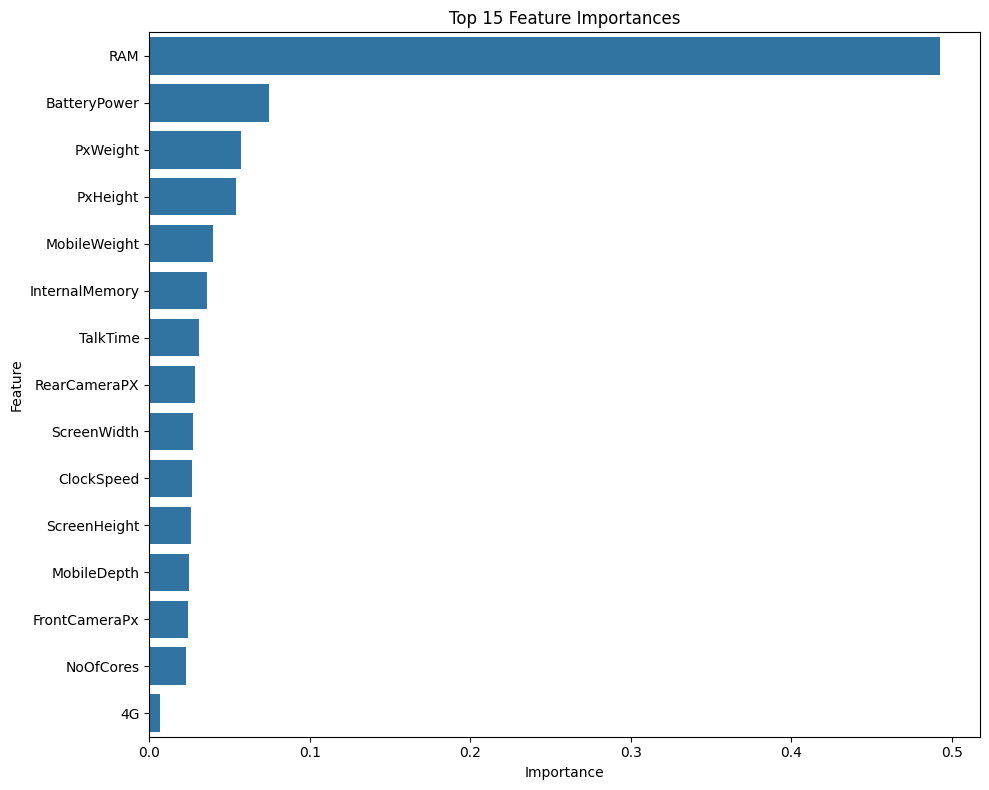

In [74]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("../images/comparison", exist_ok=True)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../images/comparison/feature_importance.png",
    dpi=300
)

plt.show()

In [75]:
processed_df = X_capped.copy()

processed_df["PriceRange"] = y_encoded

processed_df.head()

,BatteryPower,InternalMemory,ClockSpeed,NoOfCores,RAM,TalkTime,DualSim,3G,4G,WiFi,...,MobileDepth,MobileWeight,TouchScreen,ScreenHeight,ScreenWidth,FrontCameraPx,RearCameraPX,PxHeight,PxWeight,PriceRange
0,842,7,2.2,2,2549,19,0,1,0,1,...,0.6,188,0,9,7,1,2,20,756,2
1,1021,53,0.5,3,2631,7,1,1,1,0,...,0.7,136,1,17,3,0,6,905,1988,0
2,563,41,0.5,5,2603,9,1,1,1,0,...,0.9,145,1,11,2,2,6,1263,1716,0
3,615,10,2.5,6,2769,11,0,1,0,0,...,0.8,131,0,16,8,0,9,1216,1786,0
4,1821,44,1.2,2,1411,15,0,1,1,0,...,0.6,141,1,8,2,13,14,1208,1212,2


In [76]:
print("Processed Dataset Shape:", processed_df.shape)

Processed Dataset Shape: (2000, 21)


In [77]:
print("Missing Values:")
print(processed_df.isnull().sum().sum())

print("\nData Types:")
print(processed_df.dtypes)

print("\nShape:")
print(processed_df.shape)

Missing Values:
0

Data Types:
BatteryPower        int64
InternalMemory      int64
ClockSpeed        float64
NoOfCores           int64
RAM                 int64
TalkTime            int64
DualSim             int64
3G                  int64
4G                  int64
WiFi                int64
Bluetooth           int64
MobileDepth       float64
MobileWeight        int64
TouchScreen         int64
ScreenHeight        int64
ScreenWidth         int64
FrontCameraPx       int64
RearCameraPX        int64
PxHeight            int64
PxWeight            int64
PriceRange          int64
dtype: object

Shape:
(2000, 21)


In [78]:
os.makedirs("../data/processed", exist_ok=True)

In [79]:
processed_df.to_csv(
    "../data/processed/MobilePriceRange_processed.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [80]:
normalized_df = X_normalized.copy()

normalized_df["PriceRange"] = y_encoded

normalized_df.to_csv(
    "../data/processed/MobilePriceRange_normalized.csv",
    index=False
)

print("Normalized dataset saved successfully!")

Normalized dataset saved successfully!


In [81]:
standardized_df = X_standardized.copy()

standardized_df["PriceRange"] = y_encoded

standardized_df.to_csv(
    "../data/processed/MobilePriceRange_standardized.csv",
    index=False
)

print("Standardized dataset saved successfully!")

Standardized dataset saved successfully!


In [82]:
print("=" * 60)
print("TASK 4 - FEATURE ENGINEERING SUMMARY")
print("=" * 60)

print("\nOriginal Dataset:", df.shape)
print("Processed Dataset:", processed_df.shape)

print("\nPrice Range Classes:")
print(label_encoder.classes_)

print("\nMissing Values in Processed Dataset:")
print(processed_df.isnull().sum().sum())

print("\nTotal Features:", len(X_capped.columns))

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

TASK 4 - FEATURE ENGINEERING SUMMARY

Original Dataset: (2000, 21)
Processed Dataset: (2000, 21)

Price Range Classes:
['High' 'Low' 'Medium' 'VeryHigh']

Missing Values in Processed Dataset:
0

Total Features: 20

Top 10 Important Features:
           Feature  Importance
4              RAM    0.493022
0     BatteryPower    0.074776
19        PxWeight    0.056912
18        PxHeight    0.054040
12    MobileWeight    0.039479
1   InternalMemory    0.036113
5         TalkTime    0.031099
17    RearCameraPX    0.028728
15     ScreenWidth    0.027133
2       ClockSpeed    0.026595


## Conclusion

Feature engineering was successfully performed on the Mobile Price Range dataset.

- The categorical `PriceRange` target was encoded into four numerical classes.
- Numerical features were normalized using Min-Max Scaling.
- Numerical features were standardized using StandardScaler.
- Potential outliers were identified using the IQR method and handled using value capping.
- Random Forest feature importance was used to rank the predictive features.
- Clean, normalized, standardized, and processed datasets were saved for further machine learning tasks.

The processed dataset is now ready for classification model development.